# Whale–Vessel Collision Risk Analysis — California Coast

End-to-end pipeline (2020–2025). Sections match the methodology in `README.md`:

0. Setup
1. Data Preparation
2. Study Area
3. Spatial Framework (fishnet)
4. Spatial Aggregation (snap vessels, speed weighting)
5. Risk Calculation
6. Spatial Analysis (LISA)
7. Temporal Analysis
8. Outputs (GeoTIFF + maps)

Each section loads → filters → transforms → computes → saves, and writes its
outputs to `processed/` so downstream sections can pick them up.

## 0. Setup

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa: F401  (activates .rio accessor)
import matplotlib.pyplot as plt
from shapely.geometry import box

# Paths
WHALE_DIR   = Path('WhaleWatch')
GFW_CSV     = Path('gfw_presence_2020_2025_all.csv')
STATES_SHP  = Path('tl_2024_us_state/tl_2024_us_state.shp')
OUT         = Path('processed'); OUT.mkdir(parents=True, exist_ok=True)

# Constants
CRS_LONLAT = 'EPSG:4326'           # WGS84 — whale + GFW + final outputs
CRS_METRIC = 'EPSG:3310'           # California Albers — for metric buffer
CELL_SIZE  = 0.25                  # WhaleWatch grid resolution
BUFFER_KM  = 200                   # coastal study buffer

# Validation sets / weights
EXPECTED_VESSELS     = {'cargo', 'fishing'}
SPEED_BAND_ORDER     = ['<2','2-4','4-6','6-10','10-15','15-25','>25']
SPEED_WEIGHTS = {
    '<2': 0.2, '2-4': 0.2, '4-6': 0.2, '6-10': 0.2,
    '10-15': 0.6, '15-25': 1.0, '>25': 1.2,
}
SEASONS = {12:'winter', 1:'winter', 2:'winter',
           3:'spring', 4:'spring', 5:'spring',
           6:'summer', 7:'summer', 8:'summer',
           9:'fall',  10:'fall',  11:'fall'}

# Study bbox
LON_MIN, LON_MAX = -135.0, -115.0
LAT_MIN, LAT_MAX = 30.0, 49.0

## 1. Data Preparation

### 1a. NOAA WhaleWatch — combine monthly CSVs, fix longitude, drop NA model rows

In [3]:
# --- LOAD ALL FILES ---
all_files = sorted(WHALE_DIR.glob("WhaleWatchPredictions_*.csv"))
print(f"Found {len(all_files)} files")

frames = []
loaded = []

for f in all_files:
    # Parse year and month from filename e.g. WhaleWatchPredictions_2020_02.csv
    parts = f.stem.split("_")
    year  = int(parts[1])
    month = int(parts[2])

    df = pd.read_csv(f)
    df["year"]  = year
    df["month"] = month
    frames.append(df)
    loaded.append((year, month))

df_all = pd.concat(frames, ignore_index=True)
print(f"Combined shape: {df_all.shape}")
print(f"\nColumns: {list(df_all.columns)}")

# --- CONVERT LONGITUDE from 0-360 to -180 to 180 ---
df_all["longitude"] = df_all["longitude"].apply(lambda x: x - 360 if x > 180 else x)
print(f"Longitude range: {df_all['longitude'].min():.2f} to {df_all['longitude'].max():.2f}")
print(f"Latitude range:  {df_all['latitude'].min():.2f} to {df_all['latitude'].max():.2f}")

# --- IDENTIFY MISSING MONTHS ---
# Build full expected set of months 2020-01 through 2025-12
expected = set()
for y in range(2020, 2026):
    for m in range(1, 13):
        expected.add((y, m))

loaded_set = set(loaded)
missing    = sorted(expected - loaded_set)

print(f"Expected months: {len(expected)}")
print(f"Loaded months:   {len(loaded_set)}")
print(f"Missing months:  {len(missing)}")
print()

if missing:
    print("Missing month list:")
    for y, m in missing:
        print(f"  {y}-{m:02d}")

# --- SAVE MISSING MONTHS LOG ---
log_path = OUT / "whale_watch_missing_months.txt"
with open(log_path, "w") as f:
    f.write("NOAA WhaleWatch — Missing Months Log\n")
    f.write("Expected range: 2020-01 through 2025-12\n")
    f.write(f"Expected: {len(expected)} months\n")
    f.write(f"Loaded:   {len(loaded_set)} months\n")
    f.write(f"Missing:  {len(missing)} months\n\n")
    if missing:
        for y, m in missing:
            f.write(f"  {y}-{m:02d}\n")
    else:
        f.write("  None — all months present\n")

print(f"Missing months log saved to {log_path}")

# --- CHECK NA VALUES ---
print("NA counts per column:")
print(df_all.isnull().sum())
print()

# Rows where model output is NA (fitmean is null)
na_rows = df_all[df_all["fitmean"].isnull()]
print(f"Rows with no model output (fitmean = NA): {len(na_rows):,}")
print(f"Rows with model output:                   {len(df_all) - len(na_rows):,}")

# --- DROP NA MODEL OUTPUT ROWS ---
# NA fitmean means the model could not produce an estimate for that cell-month
# These are excluded from analysis
df_all["has_model_output"] = df_all["fitmean"].notna()

df_clean = df_all.copy()
print(f"Total rows: {len(df_clean):,}")
print(f"Rows with model output:    {df_clean['has_model_output'].sum():,}")
print(f"Rows without model output: {(~df_clean['has_model_output']).sum():,}")

# --- QUICK SUMMARY ---
print("Years present:", sorted(df_clean["year"].unique()))
print("Months per year:")
print(df_clean.groupby("year")["month"].nunique())
print()
print("Whale density (fitmean) summary:")
print(df_clean["fitmean"].describe())
print()
print("Presence probability (percent) summary:")
print(df_clean["percent"].describe())

# --- SAVE COMBINED FILE ---
out_path = OUT / "whale_watch_2020_2025_combined.csv"
df_clean.to_csv(out_path, index=False)
print(f"Saved to {out_path}")
print(f"File size: {out_path.stat().st_size / 1024 / 1024:.1f} MB")

# --- PREPARE FOR DOWNSTREAM JOIN ---
# Keep only rows with model output, rename lat/lon, and snap to the 0.25°
# lattice so merges with the fishnet and GFW use clean keys.
whale = df_clean[df_clean["has_model_output"]].copy()
whale = whale.rename(columns={"latitude": "cell_lat", "longitude": "cell_lon"})
whale["cell_lat"] = np.round(whale["cell_lat"] / CELL_SIZE) * CELL_SIZE
whale["cell_lon"] = np.round(whale["cell_lon"] / CELL_SIZE) * CELL_SIZE
print(f"\nWhale frame for downstream pipeline: {len(whale):,} rows")

df_clean.head()


Found 64 files
Combined shape: (399168, 18)

Columns: ['Unnamed: 0', 'longitude', 'latitude', 'bathy', 'bathyrms', 'sst', 'chl', 'ssh', 'sshrms', 'month', 'year', 'fitmean', 'sdfit', 'percent', 'density', 'sddens', 'upper', 'lower']
Longitude range: -135.00 to -115.00
Latitude range:  30.00 to 49.00
Expected months: 72
Loaded months:   64
Missing months:  8

Missing month list:
  2020-08
  2022-12
  2024-04
  2024-10
  2024-11
  2025-03
  2025-09
  2025-10
Missing months log saved to processed/whale_watch_missing_months.txt
NA counts per column:
Unnamed: 0         0
longitude          0
latitude           0
bathy         139264
bathyrms      139264
sst           131628
chl           136405
ssh           137057
sshrms        139623
month              0
year               0
fitmean       158383
sdfit         158383
percent       158383
density       158383
sddens        158383
upper         158383
lower         158383
dtype: int64

Rows with no model output (fitmean = NA): 158,383
Rows w

,Unnamed: 0,longitude,latitude,bathy,bathyrms,sst,chl,ssh,sshrms,month,year,fitmean,sdfit,percent,density,sddens,upper,lower,has_model_output
0,1,-134.75,30.00,-4846.00,138.031570,17.737705,0.109308,0.041150,NaN,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2,-134.75,30.25,-4825.75,189.851151,17.554877,0.111902,0.046869,NaN,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,3,-134.75,30.50,-4808.50,75.292976,17.444814,0.114568,0.040419,NaN,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,4,-134.75,30.75,-4745.00,81.985107,17.348983,0.113918,0.034044,0.013109,1,2020,0.056487,0.022872,5.648667,0.012769,0.003799,7.935913,3.361420,True
4,5,-134.75,31.00,-4695.00,160.621368,17.108766,0.116488,0.043225,0.014208,1,2020,0.049056,0.019097,4.905648,0.011104,0.003143,6.815389,2.995906,True


### 1b. GFW AIS — validate, filter to bbox, aggregate across flags

In [4]:
gfw = pd.read_csv(GFW_CSV)
print(f'GFW raw rows: {len(gfw):,}')

# Validate
assert not (set(gfw['vessel_type'].unique()) - EXPECTED_VESSELS)
assert not (set(gfw['speed_band'].unique())  - set(SPEED_BAND_ORDER))

# Filter to study bbox + drop null hours
gfw = gfw[(gfw['lon'].between(LON_MIN, LON_MAX)) &
          (gfw['lat'].between(LAT_MIN, LAT_MAX)) &
          gfw['hours'].notna()].copy()

# Aggregate across flags
gfw = (gfw.groupby(['year','month','lat','lon','vessel_type','speed_band'],
                    as_index=False)
          .agg(hours=('hours','sum'), vesselIDs=('vesselIDs','sum')))
print(f'GFW after flag-aggregation: {len(gfw):,}')

GFW raw rows: 4,370,448
GFW after flag-aggregation: 2,544,549


### 1c. California boundary — load TIGER, extract CA, reproject to WGS84

In [5]:
states = gpd.read_file(STATES_SHP)
ca = states[states['STUSPS'] == 'CA'].to_crs(CRS_LONLAT).copy()
print(f'CA bounds (lon/lat): {ca.total_bounds}')

CA bounds (lon/lat): [-124.482003   32.529508 -114.131211   42.009503]


## 2. Study Area

Buffer CA by 200 km in California Albers, reproject back to WGS84. Cells are
all offshore so we must use a coastal buffer (not the land polygon) for clipping.

In [6]:
ca_metric   = ca.to_crs(CRS_METRIC)
ca_buffered = ca_metric.copy()
ca_buffered['geometry'] = ca_metric.geometry.buffer(BUFFER_KM * 1000)
study_area  = ca_buffered.to_crs(CRS_LONLAT)
study_geom  = (study_area.union_all() if hasattr(study_area, 'union_all')
               else study_area.unary_union)
print(f'Study area bounds: {study_area.total_bounds}')

Study area bounds: [-126.84121804   30.72104585 -111.95916014   43.81602445]


## 3. Spatial Framework — Fishnet

Use the WhaleWatch 0.25° grid directly as the fishnet. Build one square polygon
per unique whale-cell center, clip to the study area, assign a stable `cell_id`.

In [7]:
def cell_polygon(lon, lat, size=CELL_SIZE):
    half = size / 2
    return box(lon - half, lat - half, lon + half, lat + half)

centers = whale[['cell_lat','cell_lon']].drop_duplicates().reset_index(drop=True)
grid = gpd.GeoDataFrame(
    centers.rename(columns={'cell_lat':'lat','cell_lon':'lon'}),
    geometry=[cell_polygon(r.cell_lon, r.cell_lat) for r in centers.itertuples()],
    crs=CRS_LONLAT,
)
grid = grid[grid.intersects(study_geom)].reset_index(drop=True)
grid = grid.sort_values(['lat','lon']).reset_index(drop=True)
grid['cell_id'] = grid.index.astype(int)
grid = grid[['cell_id','lat','lon','geometry']]
print(f'Fishnet cells inside study area: {len(grid):,}')

Fishnet cells inside study area: 676


## 4. Spatial Aggregation

Snap GFW (0.1°) to the 0.25° whale grid, aggregate hours per
(year, month, cell_id, vessel_type, speed_band), then pivot to wide and join
onto the whale data.

In [8]:
def snap(x, step=CELL_SIZE):
    return np.round(x / step) * step

# Attach cell_id to whale
grid_keys = grid[['cell_id','lat','lon']].rename(
    columns={'lat':'cell_lat','lon':'cell_lon'})
whale = whale.merge(grid_keys, on=['cell_lat','cell_lon'], how='inner')
print(f'Whale rows after clipping to study area: {len(whale):,}')

# Snap GFW to grid, attach cell_id
gfw['cell_lat'] = snap(gfw['lat'])
gfw['cell_lon'] = snap(gfw['lon'])
gfw = gfw.merge(grid_keys, on=['cell_lat','cell_lon'], how='inner')
print(f'GFW rows after clipping to study area:   {len(gfw):,}')

Whale rows after clipping to study area: 43,182
GFW rows after clipping to study area:   599,041


In [9]:
# Long: one row per cell-month-vesseltype-speedband
gfw_long = (gfw.groupby(['year','month','cell_id','vessel_type','speed_band'],
                         as_index=False)['hours'].sum())

# Wide: one column per vessel_type × speed_band
gfw_wide = (gfw_long.pivot_table(
                index=['year','month','cell_id'],
                columns=['vessel_type','speed_band'],
                values='hours', aggfunc='sum', fill_value=0)
            .reindex(columns=pd.MultiIndex.from_product(
                [sorted(EXPECTED_VESSELS), SPEED_BAND_ORDER]), fill_value=0))
gfw_wide.columns = [f'hours_{v}_{s}' for v, s in gfw_wide.columns]
gfw_wide = gfw_wide.reset_index()

# Join whale + vessel
whale_keep = ['year','month','cell_id','cell_lat','cell_lon',
              'fitmean','percent','sst','chl','bathy']
joined = whale[whale_keep].merge(gfw_wide, on=['year','month','cell_id'], how='left')
hours_cols = [c for c in joined.columns if c.startswith('hours_')]
joined[hours_cols] = joined[hours_cols].fillna(0)
print(f'Joined table: {joined.shape}')

Joined table: (43182, 24)


## 5. Risk Calculation

Speed-band weights follow the lethal-strike literature (Conn & Silber 2013).
`exposure_total = Σ(hours × weight)`; `risk = whale_prob × exposure_total`.
`risk_log` dampens the long tail of vessel hours for downstream maps + LISA.

In [10]:
def weighted_exposure(df_in, vessel_types):
    out = pd.DataFrame(index=df_in.index)
    for v in vessel_types:
        cols = [f'hours_{v}_{s}' for s in SPEED_WEIGHTS]
        wts  = np.array([SPEED_WEIGHTS[s] for s in SPEED_WEIGHTS])
        out[f'exposure_{v}'] = df_in[cols].to_numpy() @ wts
    out['exposure_total'] = out[[f'exposure_{v}' for v in vessel_types]].sum(axis=1)
    return out

risk = pd.concat(
    [joined, weighted_exposure(joined, sorted(EXPECTED_VESSELS))], axis=1)
risk['whale_prob']  = risk['percent'] / 100.0
risk['risk']        = risk['whale_prob'] * risk['exposure_total']
risk['risk_log']    = risk['whale_prob'] * np.log1p(risk['exposure_total'])
risk['season']      = risk['month'].map(SEASONS)
risk['time']        = pd.to_datetime(risk[['year','month']].assign(day=1))
print(risk[['whale_prob','exposure_total','risk','risk_log']].describe().round(3))

       whale_prob  exposure_total       risk   risk_log
count   43182.000       43182.000  43182.000  43182.000
mean        0.287          27.338     10.064      0.752
std         0.292          76.941     43.738      0.972
min         0.000           0.000      0.000      0.000
25%         0.044           4.600      0.328      0.087
50%         0.171          10.000      1.438      0.354
75%         0.467          22.800      5.273      1.029
max         0.997        2492.400   2125.338      7.057


## 6. Spatial Analysis — LISA

Queen contiguity weights on the fishnet. Global Moran's I plus Local Moran
cluster labels (HH / LL / HL / LH / ns at p ≤ 0.05) for the overall mean and
for each year.

In [12]:
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

W = Queen.from_dataframe(grid, use_index=False)
W.transform = 'r'
print(f'Weights: n={W.n}, mean neighbors={W.mean_neighbors:.2f}, islands={len(W.islands)}')

def classify_lisa(y, lisa, p_thresh=0.05):
    y_std = (y - y.mean()) / y.std(ddof=0)
    lag   = lisa.w.sparse @ y_std
    sig   = lisa.p_sim <= p_thresh
    label = np.full(len(y), 'ns', dtype=object)
    label[sig & (y_std > 0) & (lag > 0)] = 'HH'
    label[sig & (y_std < 0) & (lag < 0)] = 'LL'
    label[sig & (y_std > 0) & (lag < 0)] = 'HL'
    label[sig & (y_std < 0) & (lag > 0)] = 'LH'
    return label

def cell_values(df_in, value_col):
    vals = (grid[['cell_id']].merge(df_in, on='cell_id', how='left')
            [value_col].fillna(0).to_numpy())
    return vals

Weights: n=676, mean neighbors=7.25, islands=0


In [18]:
# Overall LISA (2020-2025)
overall = (risk.groupby('cell_id', as_index=False)['risk_log']
               .mean().rename(columns={'risk_log':'risk_mean'}))
y_overall   = cell_values(overall, 'risk_mean')
m_global   = Moran(y_overall, W, permutations=999)
lm_overall = Moran_Local(y_overall, W, permutations=999)


lisa_overall = grid.copy()
lisa_overall['risk_mean'] = y_overall
lisa_overall['Is']        = lm_overall.Is
lisa_overall['p_sim']     = lm_overall.p_sim
lisa_overall['cluster']   = classify_lisa(y_overall, lm_overall)
print(f"Overall Moran's I = {m_global.I:.3f} (p={m_global.p_sim:.4f})")
print(lisa_overall['cluster'].value_counts())

Overall Moran's I = 0.840 (p=0.0010)
cluster
ns    354
LL    209
HH    113
Name: count, dtype: int64


In [21]:
# Per-year LISA
yearly_mean = (risk.groupby(['cell_id','year'], as_index=False)['risk_log']
                    .mean().rename(columns={'risk_log':'risk_mean'}))

year_frames, global_rows = [], [{'scope':'overall','year':None,
                                 'I':m_global.I,'p':m_global.p_sim,'n':W.n}]
for yr in sorted(yearly_mean['year'].unique()):
    y_vals = cell_values(yearly_mean[yearly_mean['year']==yr], 'risk_mean')
    mg     = Moran(y_vals, W, permutations=999)
    lm     = Moran_Local(y_vals, W, permutations=999)
    frame  = grid[['cell_id','geometry']].copy()
    frame['year']      = yr
    frame['risk_mean'] = y_vals
    frame['Is']        = lm.Is
    frame['p_sim']     = lm.p_sim
    frame['cluster']   = classify_lisa(y_vals, lm)
    year_frames.append(frame)
    global_rows.append({'scope':'year','year':yr,'I':mg.I,'p':mg.p_sim,'n':W.n})
    print(f"  {yr}: I={mg.I:.3f} (p={mg.p_sim:.4f})  "
          f"HH={np.sum(frame['cluster']=='HH')}  LL={np.sum(frame['cluster']=='LL')}")

lisa_years = gpd.GeoDataFrame(pd.concat(year_frames, ignore_index=True),
                               crs=grid.crs)
moran_df   = pd.DataFrame(global_rows)

TypeError: Moran.__init__() got an unexpected keyword argument 'seed'

## 7. Temporal Analysis

Monthly seasonality, yearly trend, season × year heatmap, and a hotspot
trajectory classifier labeling each cell as persistent / emerging / fading /
intermittent / never.

In [22]:
monthly  = (risk.groupby('month')['risk_log']
                 .agg(mean_risk='mean', std_risk='std', n='count').reset_index())
seasonal = (risk.groupby(['year','season'])['risk_log']
                 .agg(mean_risk='mean', std_risk='std', n='count').reset_index())
yearly   = (risk.groupby('year')['risk_log']
                 .agg(mean_risk='mean', std_risk='std', n='count').reset_index())
print(yearly.round(3).to_string(index=False))

 year  mean_risk  std_risk    n
 2020      0.768     0.953 7435
 2021      0.683     0.943 8107
 2022      0.843     1.040 7393
 2023      0.709     0.978 8112
 2024      0.745     0.908 6074
 2025      0.775     0.993 6061


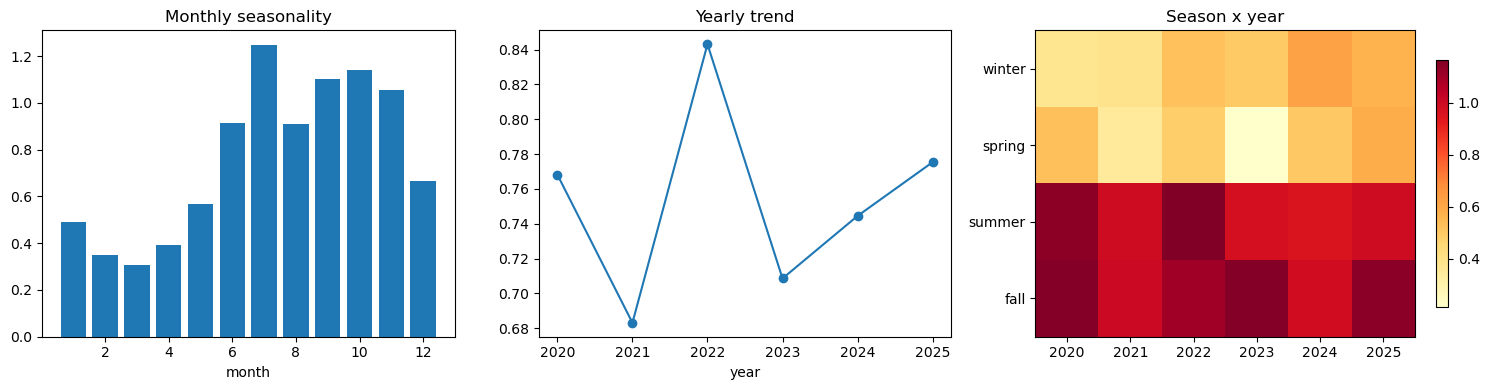

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(monthly['month'], monthly['mean_risk'])
axes[0].set_title('Monthly seasonality'); axes[0].set_xlabel('month')
axes[1].plot(yearly['year'], yearly['mean_risk'], marker='o')
axes[1].set_title('Yearly trend'); axes[1].set_xlabel('year')
pivot = (seasonal.pivot(index='season', columns='year', values='mean_risk')
                  .reindex(['winter','spring','summer','fall']))
im = axes[2].imshow(pivot.to_numpy(), aspect='auto', cmap='YlOrRd')
axes[2].set_yticks(range(len(pivot.index))); axes[2].set_yticklabels(pivot.index)
axes[2].set_xticks(range(len(pivot.columns))); axes[2].set_xticklabels(pivot.columns)
axes[2].set_title('Season x year')
fig.colorbar(im, ax=axes[2], fraction=0.03)
plt.tight_layout(); plt.show()

In [24]:
# Hotspot trajectories
hh = (lisa_years[lisa_years['cluster']=='HH'][['cell_id','year']]
      .assign(is_hh=1))
hh_wide = (hh.pivot_table(index='cell_id', columns='year',
                          values='is_hh', fill_value=0).astype(int))
years_sorted = sorted(hh_wide.columns)

def trajectory(row, years):
    vals = [row[y] for y in years]
    n = sum(vals)
    if n == 0:            return 'never'
    if n == len(years):   return 'persistent'
    h = len(vals) // 2
    first, last = sum(vals[:h]), sum(vals[h:])
    if first == 0 and last  > 0: return 'emerging'
    if last  == 0 and first > 0: return 'fading'
    return 'intermittent'

hh_wide['trajectory'] = hh_wide.apply(trajectory, axis=1, years=years_sorted)
hh_wide['n_years_hh'] = hh_wide[years_sorted].sum(axis=1)
print(hh_wide['trajectory'].value_counts())

NameError: name 'lisa_years' is not defined

## 8. Outputs

GeoTIFF raster stack (one band per month), four static PNG maps
(whale presence, vessel exposure, composite risk, LISA clusters), and a folium
time-slider HTML.

In [25]:
# --- Save tabular outputs ---
risk[['year','month','cell_id','cell_lat','cell_lon',
      'fitmean','percent','whale_prob',
      'exposure_cargo','exposure_fishing','exposure_total',
      'risk','risk_log']].to_csv(OUT / 'risk_scored.csv', index=False)

monthly.to_csv (OUT / 'temporal_monthly.csv',  index=False)
seasonal.to_csv(OUT / 'temporal_seasonal.csv', index=False)
yearly.to_csv  (OUT / 'temporal_yearly.csv',   index=False)
moran_df.to_csv(OUT / 'moran_global.csv',      index=False)

lisa_overall.to_file(OUT / 'lisa_overall.geojson', driver='GeoJSON')
lisa_years.to_file  (OUT / 'lisa_by_year.geojson', driver='GeoJSON')
grid.to_file        (OUT / 'grid_cells.geojson',   driver='GeoJSON')
hh_wide.reset_index().to_csv(OUT / 'hotspot_shifts.csv', index=False)
print('Saved tabular + LISA outputs.')

NameError: name 'moran_df' is not defined

In [26]:
# --- Build (time, lat, lon) cube and write GeoTIFF stack ---
lats = np.sort(grid['lat'].unique())
lons = np.sort(grid['lon'].unique())
times = np.sort(risk['time'].unique())

def to_raster(df_in, value_col):
    piv = (df_in.pivot_table(index='cell_lat', columns='cell_lon',
                              values=value_col, aggfunc='mean')
                .reindex(index=lats, columns=lons))
    return piv.to_numpy()

arr = np.full((len(times), len(lats), len(lons)), np.nan, dtype='float32')
for i, t in enumerate(times):
    arr[i] = to_raster(risk[risk['time']==t], 'risk_log')

cube = (xr.DataArray(arr, dims=('time','lat','lon'),
                      coords={'time':times,'lat':lats,'lon':lons},
                      name='risk_log')
          .sortby('lat', ascending=False))
cube.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
cube.rio.write_crs(CRS_LONLAT, inplace=True)
cube.rio.to_raster(OUT / 'risk_monthly.tif')
print(f'Saved risk_monthly.tif  ({len(times)} bands)')

MissingSpatialDimensionError: y dimension not found. 'rio.set_spatial_dims()' or using 'rename()' to change the dimension name to 'y' can address this. Data variable: risk_log

In [ ]:
# --- Static maps ---
cell_mean = (risk.groupby(['cell_id','cell_lat','cell_lon'], as_index=False)
                  .agg(whale_prob=('whale_prob','mean'),
                       exposure_total=('exposure_total','mean'),
                       risk_log=('risk_log','mean')))
cells_gdf = grid[['cell_id','geometry']].merge(cell_mean, on='cell_id', how='left')

def draw_map(gdf, col, title, cmap, fname):
    fig, ax = plt.subplots(figsize=(7, 9))
    gdf.plot(column=col, cmap=cmap, linewidth=0, ax=ax,
             legend=True, legend_kwds={'shrink':0.6})
    ca.boundary.plot(ax=ax, color='black', linewidth=0.5)
    ax.set_title(title); ax.set_aspect('equal'); ax.set_axis_off()
    plt.tight_layout()
    fig.savefig(OUT / fname, dpi=150, bbox_inches='tight')
    plt.show()

draw_map(cells_gdf, 'whale_prob',     'Mean whale presence 2020-2025', 'Blues',  'map_whale_presence.png')
draw_map(cells_gdf, 'exposure_total', 'Mean weighted vessel exposure', 'Greens', 'map_vessel_exposure.png')
draw_map(cells_gdf, 'risk_log',       'Mean composite risk (log)',     'YlOrRd', 'map_risk.png')

lisa_colors = {'HH':'#d7191c','LL':'#2c7bb6','HL':'#fdae61','LH':'#abd9e9','ns':'#e0e0e0'}
fig, ax = plt.subplots(figsize=(7, 9))
for cat, color in lisa_colors.items():
    sel = lisa_overall[lisa_overall['cluster']==cat]
    if len(sel):
        sel.plot(ax=ax, color=color, edgecolor='none', label=f'{cat} ({len(sel)})')
ca.boundary.plot(ax=ax, color='black', linewidth=0.5)
ax.set_title('LISA hotspots — mean risk 2020-2025')
ax.legend(loc='lower left', fontsize=8); ax.set_aspect('equal'); ax.set_axis_off()
plt.tight_layout(); fig.savefig(OUT / 'map_lisa.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# --- Interactive folium time slider ---
import folium
from folium.plugins import TimeSliderChoropleth
from branca.colormap import linear

vmax = float(np.nanpercentile(risk['risk_log'], 98))
cmap = linear.YlOrRd_09.scale(0, vmax)

tmp = risk[['cell_id','time','risk_log']].copy()
tmp['ts'] = (tmp['time'].astype('int64') // 10**9).astype(str)
style = {}
for cid, group in tmp.groupby('cell_id'):
    style[str(int(cid))] = {r['ts']: {'color': cmap(min(r['risk_log'], vmax)),
                                      'opacity': 0.75}
                             for _, r in group.iterrows()}

cells_for_map = grid[['cell_id','geometry']].copy()
cells_for_map['cell_id'] = cells_for_map['cell_id'].astype(int).astype(str)
gj = json.loads(cells_for_map.to_json())
for f in gj['features']:
    f['id'] = f['properties']['cell_id']

center = [grid.geometry.centroid.y.mean(), grid.geometry.centroid.x.mean()]
m = folium.Map(location=center, zoom_start=6, tiles='cartodbpositron')
TimeSliderChoropleth(data=json.dumps(gj), styledict=style).add_to(m)
cmap.caption = 'risk_log'; cmap.add_to(m)
m.save(str(OUT / 'interactive_risk_map.html'))
print(f'Saved {OUT/"interactive_risk_map.html"}')
m